<a href="https://colab.research.google.com/github/yasirsiddiq01/Titanic-Survival-Prediction-Logistic-Regression/blob/main/LR_Titanic_Data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import math

# URL to the raw Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# Load the data directly into a DataFrame
titanic_dataset = pd.read_csv(url)

# Display the first few rows to confirm it worked
titanic_dataset.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [37]:
#Display total number of passengers
print("Total number of passengers:"+str(len(titanic_dataset.index)))

Total number of passengers:891


<Axes: xlabel='Survived', ylabel='count'>

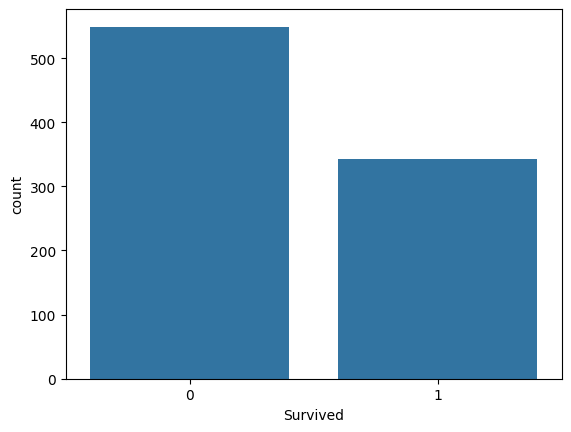

In [38]:
#analyze data
sns.countplot(x='Survived',data=titanic_dataset)

<Axes: xlabel='Survived', ylabel='count'>

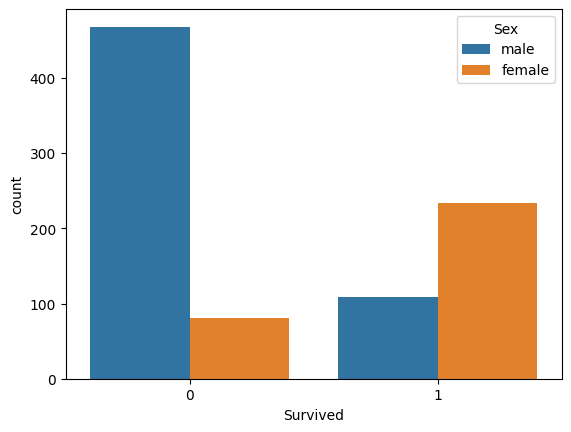

In [39]:
sns.countplot(x='Survived',hue='Sex',data=titanic_dataset)


<Axes: xlabel='Survived', ylabel='count'>

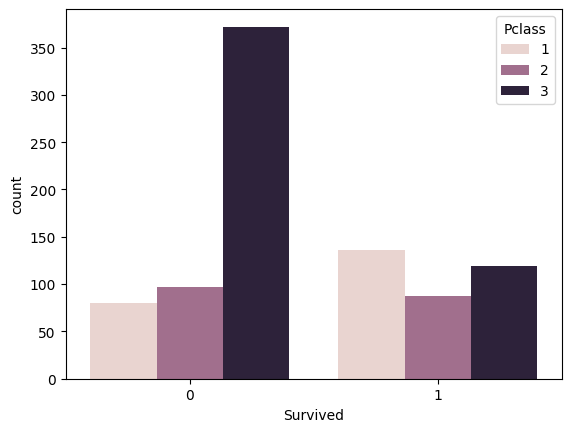

In [40]:
sns.countplot(x='Survived',hue='Pclass',data=titanic_dataset)

<Axes: ylabel='Frequency'>

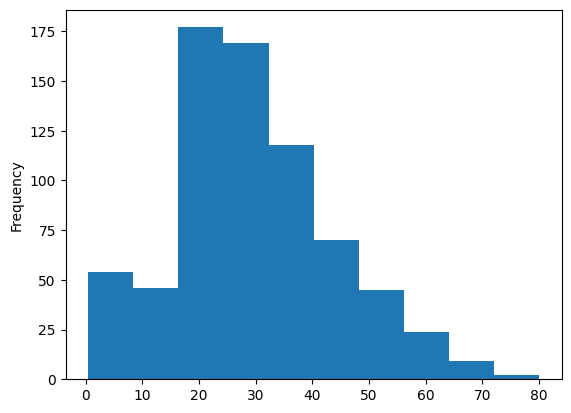

In [41]:
titanic_dataset["Age"].plot.hist()

<Axes: ylabel='Frequency'>

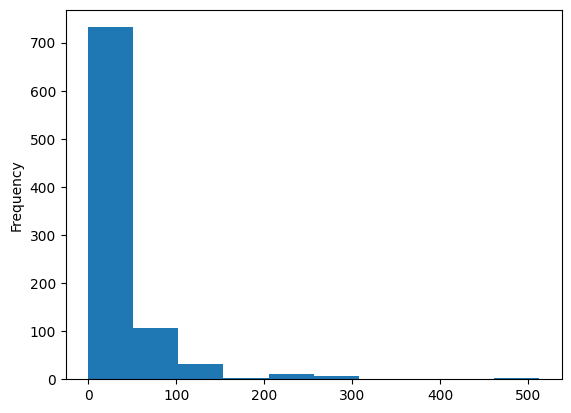

In [42]:
titanic_dataset["Fare"].plot.hist()

In [43]:
titanic_dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: xlabel='SibSp', ylabel='count'>

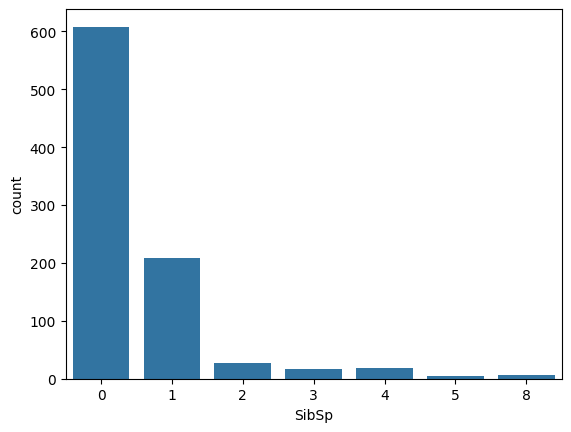

In [44]:
sns.countplot(x='SibSp',data=titanic_dataset)

In [ ]:
##Data wrangling

In [45]:
titanic_dataset.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [46]:
titanic_dataset.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: >

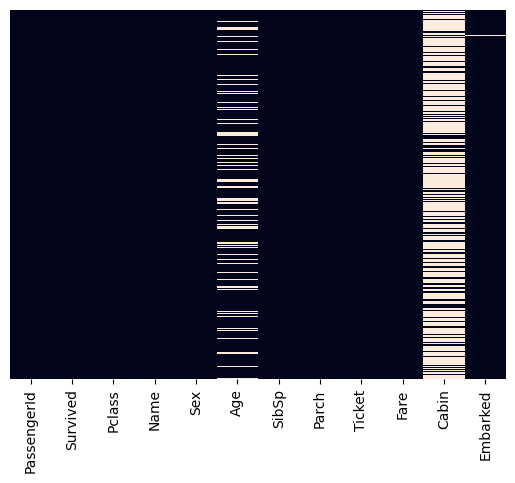

In [47]:
sns.heatmap(titanic_dataset.isnull(),yticklabels=False,cbar=False)

<Axes: >

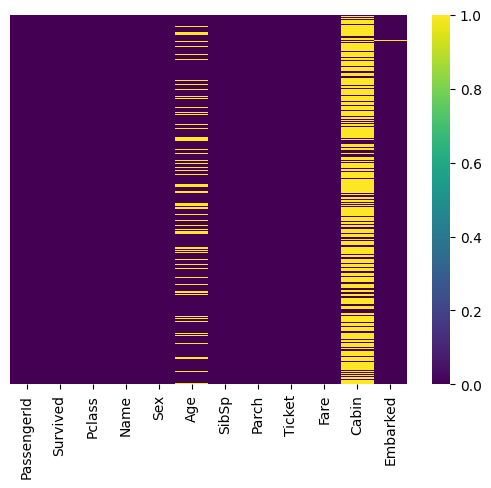

In [48]:
sns.heatmap(titanic_dataset.isnull(),yticklabels=False,cmap='viridis')

<Axes: xlabel='Pclass', ylabel='Age'>

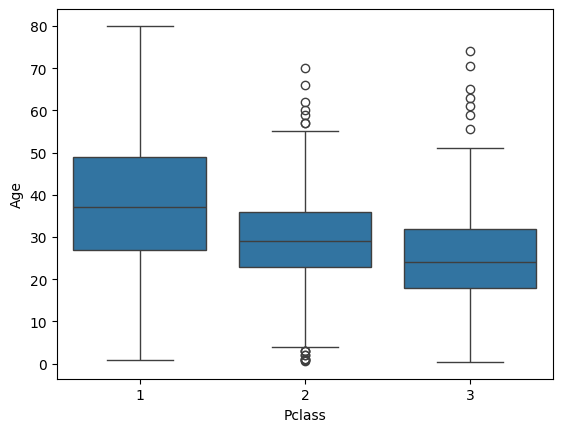

In [49]:
sns.boxplot(x='Pclass',y='Age',data=titanic_dataset)

In [50]:
titanic_dataset.drop("Cabin",axis=1,inplace=True)

In [51]:
titanic_dataset.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [52]:
titanic_dataset.dropna(inplace=True)

<Axes: >

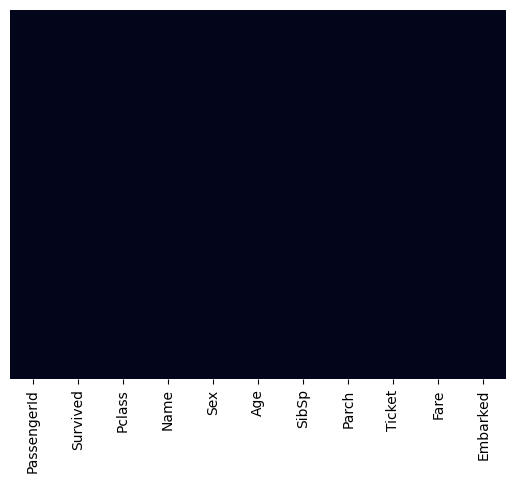

In [53]:
sns.heatmap(titanic_dataset.isnull(),yticklabels=False,cbar=False)

In [54]:
titanic_dataset.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [60]:
titanic_dataset.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


In [65]:
sex=pd.get_dummies(titanic_dataset["Sex"],drop_first=True).astype(int)
sex.head(5)

,male
0,1
1,0
2,0
3,0
4,1


In [67]:
embark=pd.get_dummies(titanic_dataset['Embarked'],drop_first=True).astype(int)
embark.head(5)

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


In [68]:
pcl=pd.get_dummies(titanic_dataset['Pclass'],drop_first=True).astype(int)
pcl.head(5)

,2,3
0,0,1
1,0,0
2,0,1
3,0,0
4,0,1


In [69]:
titanic_dataset=pd.concat([titanic_dataset,sex,embark,pcl],axis=1)

In [70]:
titanic_dataset.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S,2,3
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0,0,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,0,1,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0,0,1,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,0,1,0,1


In [71]:
titanic_dataset.drop(['PassengerId','Pclass','Embarked','Sex','Name','Ticket'],axis=1,inplace=True)

In [72]:
titanic_dataset.head(2)

,Survived,Age,SibSp,Parch,Fare,male,Q,S,2,3
0,0,22.0,1,0,7.2500,1,0,1,0,1
1,1,38.0,1,0,71.2833,0,0,0,0,0


##Train the data

In [92]:
X=titanic_dataset.drop("Survived",axis=1)
Y=titanic_dataset["Survived"]

In [94]:
X.columns = X.columns.astype(str)
#Y.columns = Y.columns.astype(str)

In [76]:
import sklearn
from sklearn.model_selection import train_test_split

In [95]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=1)

In [86]:
from sklearn.linear_model import LogisticRegression

In [87]:
titanic_dataset.head(3)

,Survived,Age,SibSp,Parch,Fare,male,Q,S,2,3
0,0,22.0,1,0,7.2500,1,0,1,0,1
1,1,38.0,1,0,71.2833,0,0,0,0,0
2,1,26.0,0,0,7.9250,0,0,1,0,1


In [96]:
logmodel=LogisticRegression()
logmodel.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [97]:
predictions=logmodel.predict(X_test)

In [98]:
from sklearn.metrics import classification_report

In [99]:
classification_report(y_test,predictions)

'              precision    recall  f1-score   support\n\n           0       0.80      0.81      0.81       126\n           1       0.72      0.72      0.72        88\n\n    accuracy                           0.77       214\n   macro avg       0.76      0.76      0.76       214\nweighted avg       0.77      0.77      0.77       214\n'

In [100]:
from sklearn.metrics import confusion_matrix

In [101]:
confusion_matrix(y_test,predictions)

array([[102,  24],
       [ 25,  63]])

In [102]:
from sklearn.metrics import accuracy_score

In [103]:
accuracy_score(y_test,predictions)

0.7710280373831776

"""
Titanic Survival Prediction - Learning Project
Author: Yasir Siddiq
Purpose: Practice logistic regression, data preprocessing, and EDA
Tutorial Reference: Based on YouTube tutorials for educational purposes
Date: 22-March-2026

"""

In [105]:
# Add comments showing my understanding
def explain_preprocessing():
   # """
    #MY UNDERSTANDING:
    #- Dropped Cabin because 77% missing values (would introduce too much noise)
    #- One-hot encoded Sex and Embarked to convert categorical to numerical
    #- Dropped PassengerId, Name, Ticket as they're unique identifiers (no predictive value)
    #- Used dropna() after analysis to handle remaining missing values
    #- Use astype(int) to convert to integers
    #"""
    pass

#
print("\n=== MY ANALYSIS INSIGHTS ===")
print("1. Sex was the strongest predictor - females had ~74% survival rate")
print("2. Pclass showed clear socioeconomic impact on survival")
print("3. Age distribution showed children had higher survival rates")
print("4. Logistic regression achieved ~77% accuracy on test data")


=== MY ANALYSIS INSIGHTS ===
1. Sex was the strongest predictor - females had ~74% survival rate
2. Pclass showed clear socioeconomic impact on survival
3. Age distribution showed children had higher survival rates
4. Logistic regression achieved ~77% accuracy on test data


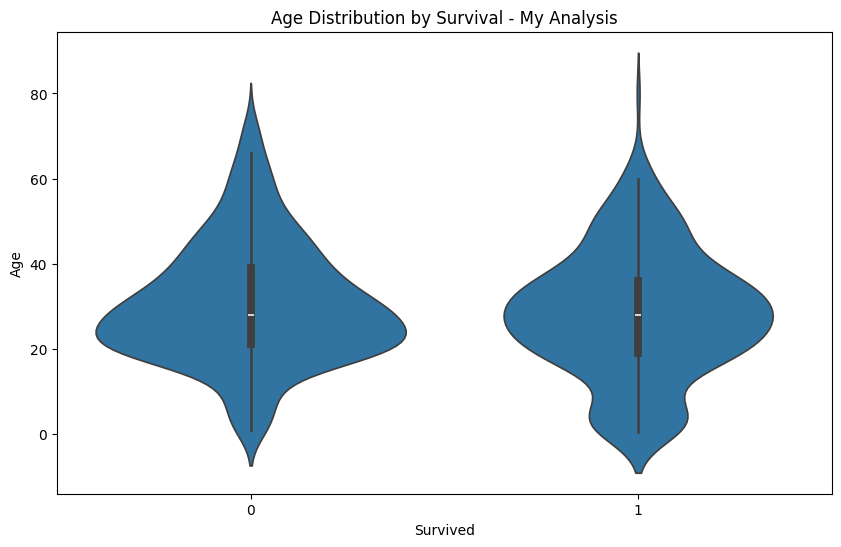

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: 0.7710
Random Forest: 0.7570
SVM: 0.6495


In [107]:
# Example 1: Feature engineering
titanic_dataset['FamilySize'] = titanic_dataset['SibSp'] + titanic_dataset['Parch'] + 1
titanic_dataset['IsAlone'] = (titanic_dataset['FamilySize'] == 1).astype(int)

# Example 2: Different visualization
plt.figure(figsize=(10,6))
sns.violinplot(x='Survived', y='Age', data=titanic_dataset)
plt.title('Age Distribution by Survival - My Analysis')
plt.show()

# Example 3: Compare multiple models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name}: {score:.4f}")